# FinTrust Digital Bank — Week 2: Analyse & Prepare

**AnalystLab Africa Experience Lab Internship — Data Science Track**
**Intern:** Takudzwa Jeffrey Gumbo (TJ) | **Week 2 — Analyse & Prepare**

---

### Purpose

Week 1 defined the problem and the plan. This notebook executes it:

| Part | Content |
|---|---|
| A | Data preparation — load, join, inspect, document decisions |
| B | Exploratory data analysis — 14 visualisations on the training split |
| C | Feature engineering — 13 features, all fitted on training data only |
| D | Baseline model development — logistic regression, decision tree, random forest |
| E | Model evaluation — ROC-AUC, PR-AUC, precision, recall, F1, confusion matrix, threshold tuning |
| F | Model interpretation — coefficients, permutation importance, error analysis, limitations |

### Responsible-use statement

> All FinTrust customers, transactions and labels are **synthetic** and created for educational
> purposes. `Risk_Review_Flag` is a synthetic educational label, **not** a real fraud determination.
> Nothing here may be used to make real financial decisions or presented as evidence about real
> financial crime.

### Methodological commitments carried over from Week 1

1. The train/validation/test split is created **before** any exploratory analysis or feature engineering.
2. All EDA is performed on the **training split only**.
3. Every derived statistic (customer means, quantile cut points) is computed on **training data only**.
4. The **test set is not touched in Week 2** — it is scored once, in Week 4.
5. Rejected hypotheses are reported as results, not omitted.

## 0. Setup

In [12]:
"""Imports, reproducibility settings and shared plotting configuration."""
import warnings
from pathlib import Path
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix,
                             f1_score, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GroupShuffleSplit, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

NAVY, GOLD, GREY = "#1F3B63", "#D4A017", "#8C93A0"

DATA_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../reports/figures")
for directory in (PROCESSED_DIR, FIG_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def save_figure(fig, name: str) -> None:
    """Save a figure to the reports directory with a descriptive filename.

    Args:
        fig: Matplotlib figure to save.
        name: Filename stem, without extension.
    """
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")


print(f"pandas {pd.__version__} | numpy {np.__version__}")

drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/Analyst Lab Africa")

print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"Data directory: {BASE_DIR}")

pandas 2.2.3 | numpy 2.1.3
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pandas 2.2.3 | numpy 2.1.3
Data directory: /content/drive/MyDrive/Analyst Lab Africa


---
# Part A — Data Preparation

Ten preparation steps, each with the decision it produced documented in the markdown that follows it.

### A1–A3. Load both datasets and join on `Customer_ID`

In [13]:
def load_data(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load the FinTrust customer and transaction datasets."""

    customers_path = BASE_DIR / "FinTrust_Customer_Data - FinTrust_Customer_Data.csv"
    transactions_path = BASE_DIR / "FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv"

    # Check that the files exist
    if not customers_path.exists():
        raise FileNotFoundError(f"Customer file not found: {customers_path}")

    if not transactions_path.exists():
        raise FileNotFoundError(f"Transaction file not found: {transactions_path}")

    # Read CSV files
    customers = pd.read_csv(customers_path)
    transactions = pd.read_csv(transactions_path)

    # Parse transaction timestamps
    parsed = pd.to_datetime(
        transactions["Transaction_DateTime"],
        format="%m/%d/%Y %H:%M",
        errors="coerce"
    )

    if parsed.isna().any():
        raise ValueError(
            f"{parsed.isna().sum()} transaction timestamps failed to parse."
        )

    transactions["Transaction_DateTime"] = parsed

    return customers, transactions


# Load the datasets
customers, transactions = load_data(DATA_DIR)

# Merge transactions with customer information
df = transactions.merge(
    customers,
    on="Customer_ID",
    how="inner",
    validate="many_to_one"
)

# Make sure the merge did not create or lose transaction rows
assert len(df) == len(transactions), "Join changed the transaction row count"

print(f"Customers:    {customers.shape}")
print(f"Transactions: {transactions.shape}")
print(f"Merged:       {df.shape}")

Customers:    (1500, 12)
Transactions: (12000, 11)
Merged:       (12000, 22)


### A4–A8. Missing values, duplicates, data types, unusual values, target distribution

In [14]:
print("MISSING VALUES (merged dataset)")
missing = df.isna().sum()

print(
    missing[missing > 0].to_string()
    if missing.any()
    else "  none"
)

print("\nDUPLICATES")
print(f"  Duplicate Transaction_ID: {df['Transaction_ID'].duplicated().sum()}")
print(f"  Duplicate full rows:      {df.duplicated().sum()}")

print("\nDATA TYPES")
print(df.dtypes.value_counts().to_string())

print("\nUNUSUAL VALUES")

print(
    f"  Zero or negative amounts:  "
    f"{(df['Amount_NGN'] <= 0).sum()}"
)

print(
    f"  Ages outside 18-100:       "
    f"{(~df['Age'].between(18, 100)).sum()}"
)

implausible = (
    customers["Tenure_Months"]
    > (customers["Age"] - 18) * 12
)

print(
    f"  Tenure exceeding adult age: "
    f"{implausible.sum()} customers"
)

print(
    f"  Duplicated customer names:  "
    f"{customers['Customer_Name'].duplicated().sum()}"
)

print("\nTARGET DISTRIBUTION")

target_counts = df["Risk_Review_Flag"].value_counts()

print(target_counts.to_string())

print(
    f"  Positive rate: "
    f"{(df['Risk_Review_Flag'] == 'Yes').mean():.4f}"
)

MISSING VALUES (merged dataset)
Device_Type    96
Location       96

DUPLICATES
  Duplicate Transaction_ID: 0
  Duplicate full rows:      0

DATA TYPES
object            17
float64            2
int64              2
datetime64[ns]     1

UNUSUAL VALUES
  Zero or negative amounts:  0
  Ages outside 18-100:       0
  Tenure exceeding adult age: 145 customers
  Duplicated customer names:  1320

TARGET DISTRIBUTION
Risk_Review_Flag
No     9648
Yes    2352
  Positive rate: 0.1960


**Decision A1 — Missing values.** `Device_Type` and `Location` each have 96 missing values (0.80%),
overlapping in only 4 records. Dropping them would discard 192 otherwise-usable transactions for no
gain. **Decision:** impute both as an explicit `"Unknown"` category, so the model can learn from
missingness itself if it carries signal.

**Decision A2 — No row deduplication needed.** Zero duplicate transaction IDs and zero duplicate
full rows.

**Decision A3 — Retain implausible-tenure customers.** 145 customers have `Tenure_Months` exceeding
`(Age - 18) * 12`. They are retained because tenure shows no meaningful association with the target
(tested in Part B), so excluding them would cost data for no benefit. Flagged as a limitation.

In [15]:
df["Device_Type"] = df["Device_Type"].fillna("Unknown")
df["Location"] = df["Location"].fillna("Unknown")
df["target"] = (df["Risk_Review_Flag"] == "Yes").astype(int)

print(f"Remaining missing values: {df.isna().sum().sum()}")
print(f"Target encoded: {df['target'].sum():,} positive / {len(df) - df['target'].sum():,} negative")

Remaining missing values: 0
Target encoded: 2,352 positive / 9,648 negative


### A9. Variables inappropriate for modelling

In [16]:
EXCLUDED = {
    "Customer_Name": "Display field; 1,320 of 1,500 names are non-unique. Dictionary marks it as not for modelling.",
    "Customer_ID": "Identifier. Would let the model memorise individual customers rather than learn patterns.",
    "Transaction_ID": "Unique per row. Carries zero generalisable signal.",
    "Gender": "Protected attribute. Using it to prioritise transactions for review is not defensible.",
    "Transaction_DateTime": "Raw timestamp replaced by derived hour / day-of-week features.",
    "Risk_Review_Flag": "The target itself.",
    "Transaction_Status": "LEAKAGE RISK - may be set as a consequence of review. Tested separately in Part E.",
}
for field, reason in EXCLUDED.items():
    print(f"{field:22s} {reason}")

Customer_Name          Display field; 1,320 of 1,500 names are non-unique. Dictionary marks it as not for modelling.
Customer_ID            Identifier. Would let the model memorise individual customers rather than learn patterns.
Transaction_ID         Unique per row. Carries zero generalisable signal.
Gender                 Protected attribute. Using it to prioritise transactions for review is not defensible.
Transaction_DateTime   Raw timestamp replaced by derived hour / day-of-week features.
Risk_Review_Flag       The target itself.
Transaction_Status     LEAKAGE RISK - may be set as a consequence of review. Tested separately in Part E.


### A10. Train / validation / test split — created *before* any EDA

This ordering is the single most important methodological decision in the notebook. Creating the
split first means that no pattern seen during exploration can influence a feature definition, and
that every derived statistic can be computed on training data only.

In [17]:
# 70 / 15 / 15 stratified split. 0.1765 of the remaining 85% gives 15% of the original.
train_val, test = train_test_split(df, test_size=0.15, stratify=df["target"], random_state=RANDOM_SEED)
train, val = train_test_split(train_val, test_size=0.1765, stratify=train_val["target"],
                              random_state=RANDOM_SEED)

for name, split in [("Train", train), ("Validation", val), ("Test", test)]:
    print(f"{name:11s} {len(split):>6,} rows   positive rate {split['target'].mean():.4f}")

print("\nThe test set is now set aside and is NOT touched again until Week 4.")

Train        8,399 rows   positive rate 0.1960
Validation   1,801 rows   positive rate 0.1960
Test         1,800 rows   positive rate 0.1961

The test set is now set aside and is NOT touched again until Week 4.


---
# Part B — Exploratory Data Analysis

All EDA below uses the **training split only**. Figures are numbered as they appear in the Week 2
report. Feature engineering (Part C) is applied first so that engineered features can be explored
alongside the raw ones — the engineering functions themselves are fitted on training data only.

---
# Part C — Feature Engineering

13 features. Every statistic used in the transformations — customer mean amounts, quantile cut
points, customer transaction counts — is computed on the **training split only** and then applied
unchanged to validation and test.

In [18]:
# --- Statistics fitted on the TRAINING split only ---
customer_mean_amount = train.groupby("Customer_ID")["Amount_NGN"].mean()
global_mean_amount = train["Amount_NGN"].mean()
customer_txn_count = train.groupby("Customer_ID").size()
amount_bins = [-np.inf] + list(np.quantile(train["Amount_NGN"], [0.2, 0.4, 0.6, 0.8])) + [np.inf]
high_value_cut = float(np.quantile(train["Amount_NGN"], 0.95))

print("Fitted on training data only:")
print(f"  Amount quintile cut points: {[round(b, 2) for b in amount_bins[1:-1]]}")
print(f"  High-value cut (95th pct):  {high_value_cut:,.2f}")
print(f"  Customers with a fitted mean: {len(customer_mean_amount):,}")

Fitted on training data only:
  Amount quintile cut points: [np.float64(1636.59), np.float64(5693.6), np.float64(19005.88), np.float64(66775.72)]
  High-value cut (95th pct):  225,482.09
  Customers with a fitted mean: 1,493


In [19]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Apply the Week 2 feature engineering using training-fitted statistics.

    All thresholds, customer means and counts are closed over from the training
    split, so applying this function to validation or test data cannot leak
    information from those splits back into the features.

    Args:
        data: A split of the merged dataset.

    Returns:
        Copy of the input with 13 engineered feature columns added.
    """
    d = data.copy()

    # Time-derived features
    d["Transaction_Hour"] = d["Transaction_DateTime"].dt.hour
    d["Is_Overnight"] = d["Transaction_Hour"].between(0, 5).astype(int)
    d["Transaction_DayOfWeek"] = d["Transaction_DateTime"].dt.day_name()
    d["Is_Weekend"] = d["Transaction_DateTime"].dt.dayofweek.isin([5, 6]).astype(int)

    # Amount-derived features
    d["Amount_Log"] = np.log1p(d["Amount_NGN"])
    d["Amount_Band"] = pd.cut(d["Amount_NGN"], amount_bins,
                              labels=["Q1", "Q2", "Q3", "Q4", "Q5"]).astype(str)
    d["Is_High_Value"] = (d["Amount_NGN"] > high_value_cut).astype(int)

    # Customer-relative behavioural features
    d["Cust_Mean_Amount"] = d["Customer_ID"].map(customer_mean_amount).fillna(global_mean_amount)
    d["Amount_vs_Cust_Mean"] = d["Amount_NGN"] / d["Cust_Mean_Amount"]
    d["Cust_Txn_Count"] = d["Customer_ID"].map(customer_txn_count).fillna(0).astype(int)

    # Categorical banding and indicators
    d["Is_International"] = (d["International_Transaction"] == "Yes").astype(int)
    d["Tenure_Band"] = pd.cut(d["Tenure_Months"], [0, 12, 36, 60, 96],
                              labels=["0-12m", "13-36m", "37-60m", "61-96m"]).astype(str)
    d["Engagement_Band"] = pd.cut(d["Digital_Engagement_Score"], [0, 40, 70, 100],
                                  labels=["Low", "Medium", "High"]).astype(str)
    return d


train_f = engineer_features(train)
val_f = engineer_features(val)
test_f = engineer_features(test)

# Save the full prepared modelling dataset as a Week 2 deliverable.
engineer_features(df).to_csv(PROCESSED_DIR / "fintrust_modelling_dataset.csv", index=False)

print(f"Engineered training split: {train_f.shape}")
print("New columns:", [c for c in train_f.columns if c not in df.columns])

Engineered training split: (8399, 36)
New columns: ['Transaction_Hour', 'Is_Overnight', 'Transaction_DayOfWeek', 'Is_Weekend', 'Amount_Log', 'Amount_Band', 'Is_High_Value', 'Cust_Mean_Amount', 'Amount_vs_Cust_Mean', 'Cust_Txn_Count', 'Is_International', 'Tenure_Band', 'Engagement_Band']


### B1. Target distribution on the training split

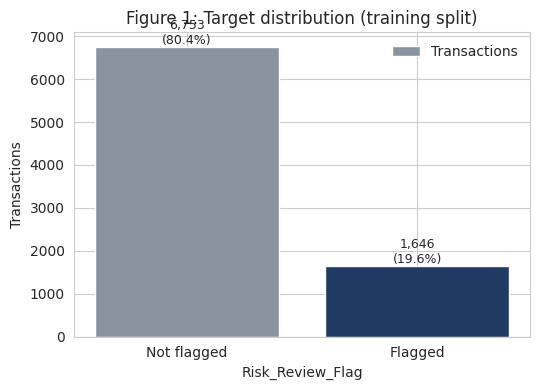

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 4))
counts = train_f["Risk_Review_Flag"].value_counts()
bars = ax.bar(["Not flagged", "Flagged"], [counts["No"], counts["Yes"]],
              color=[GREY, NAVY], label="Transactions")
for bar, value in zip(bars, [counts["No"], counts["Yes"]]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 60,
            f"{value:,}\n({value / len(train_f) * 100:.1f}%)", ha="center", fontsize=9)
ax.set(title="Figure 1: Target distribution (training split)",
       xlabel="Risk_Review_Flag", ylabel="Transactions")
ax.legend(frameon=False)
save_figure(fig, "fig01_target_distribution")
plt.show()

### B2. Transaction amount versus the review flag

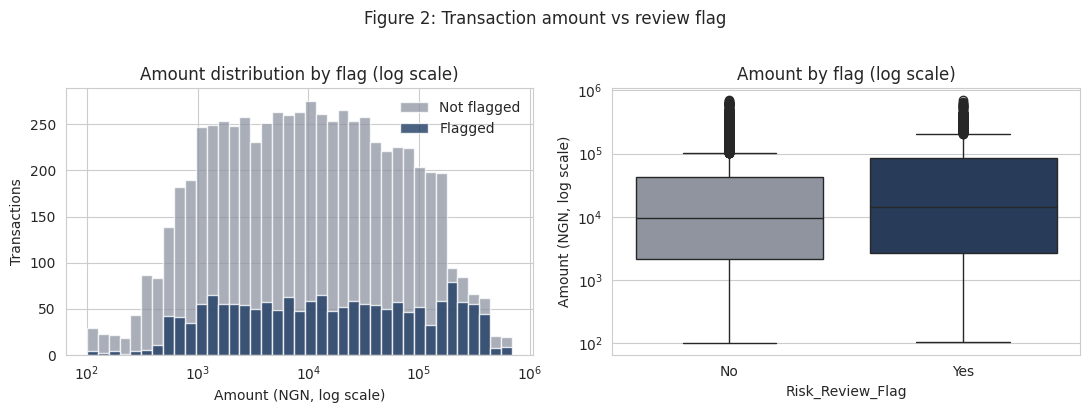

                   count     mean       std    min     25%      50%      75%       max
Risk_Review_Flag                                                                      
No                6753.0  41146.0   77436.0  100.0  2168.0   9631.0  42498.0  693007.0
Yes               1646.0  69322.0  110450.0  103.0  2669.0  14311.0  84558.0  693454.0


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = np.logspace(np.log10(train_f["Amount_NGN"].min()),
                   np.log10(train_f["Amount_NGN"].max()), 40)
axes[0].hist(train_f.loc[train_f.target == 0, "Amount_NGN"], bins=bins,
             color=GREY, alpha=0.75, label="Not flagged")
axes[0].hist(train_f.loc[train_f.target == 1, "Amount_NGN"], bins=bins,
             color=NAVY, alpha=0.80, label="Flagged")
axes[0].set_xscale("log")
axes[0].set(title="Amount distribution by flag (log scale)",
            xlabel="Amount (NGN, log scale)", ylabel="Transactions")
axes[0].legend(frameon=False)

sns.boxplot(data=train_f, x="Risk_Review_Flag", y="Amount_NGN", order=["No", "Yes"],
            hue="Risk_Review_Flag", palette={"No": GREY, "Yes": NAVY}, legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set(title="Amount by flag (log scale)", xlabel="Risk_Review_Flag",
            ylabel="Amount (NGN, log scale)")
fig.suptitle("Figure 2: Transaction amount vs review flag", y=1.02)
save_figure(fig, "fig02_amount_vs_flag")
plt.show()

print(train_f.groupby("Risk_Review_Flag")["Amount_NGN"].describe().round(0).to_string())

### B3–B8. Flag rate across candidate drivers

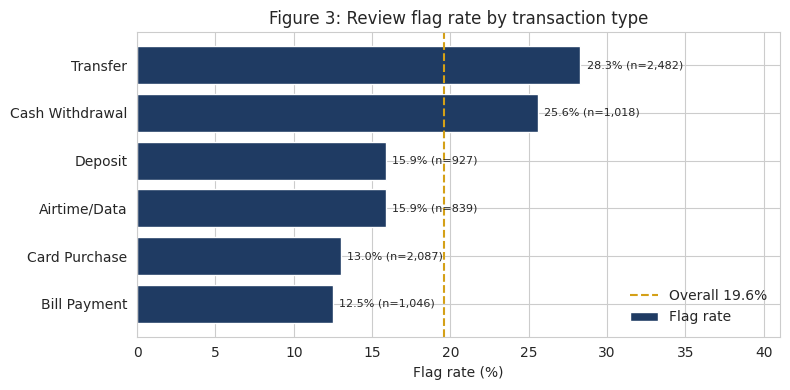

In [22]:
def flag_rate_by(data: pd.DataFrame, column: str) -> pd.DataFrame:
    """Compute descriptive flag rate and record count per level of a column.

    Args:
        data: Dataset containing the column and the encoded target.
        column: Grouping column name.

    Returns:
        DataFrame of flag rate (%) and count per level, sorted ascending by rate.
    """
    grouped = data.groupby(column)["target"].agg(["mean", "count"])
    grouped.columns = ["flag_rate_pct", "n"]
    grouped["flag_rate_pct"] = (grouped["flag_rate_pct"] * 100).round(1)
    return grouped.sort_values("flag_rate_pct")


def plot_flag_rate(ax, data: pd.DataFrame, column: str, title: str) -> None:
    """Draw a horizontal flag-rate bar chart with an overall-rate reference line.

    Args:
        ax: Matplotlib axis to draw on.
        data: Dataset to summarise.
        column: Grouping column.
        title: Axis title.
    """
    rates = flag_rate_by(data, column)
    overall = data["target"].mean() * 100
    ax.barh(rates.index.astype(str), rates["flag_rate_pct"], color=NAVY, label="Flag rate")
    ax.axvline(overall, color=GOLD, linestyle="--", linewidth=1.5, label=f"Overall {overall:.1f}%")
    for y, (_, row) in enumerate(rates.iterrows()):
        ax.text(row["flag_rate_pct"] + 0.4, y,
                f"{row['flag_rate_pct']:.1f}% (n={int(row['n']):,})", va="center", fontsize=8)
    ax.set(title=title, xlabel="Flag rate (%)",
           xlim=(0, rates["flag_rate_pct"].max() * 1.45))


fig, ax = plt.subplots(figsize=(8, 4))
plot_flag_rate(ax, train_f, "Transaction_Type", "Figure 3: Review flag rate by transaction type")
ax.legend(frameon=False, loc="lower right")
save_figure(fig, "fig03_flagrate_transaction_type")
plt.show()

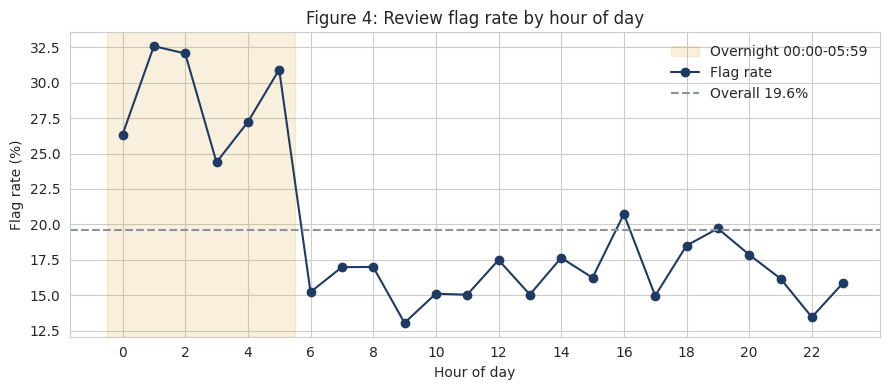

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
hourly = train_f.groupby("Transaction_Hour")["target"].mean() * 100
overall = train_f["target"].mean() * 100
ax.axvspan(-0.5, 5.5, color=GOLD, alpha=0.15, label="Overnight 00:00-05:59")
ax.plot(hourly.index, hourly.values, marker="o", color=NAVY, label="Flag rate")
ax.axhline(overall, color=GREY, linestyle="--", linewidth=1.5, label=f"Overall {overall:.1f}%")
ax.set(title="Figure 4: Review flag rate by hour of day", xlabel="Hour of day",
       ylabel="Flag rate (%)", xticks=range(0, 24, 2))
ax.legend(frameon=False)
save_figure(fig, "fig04_flagrate_by_hour")
plt.show()

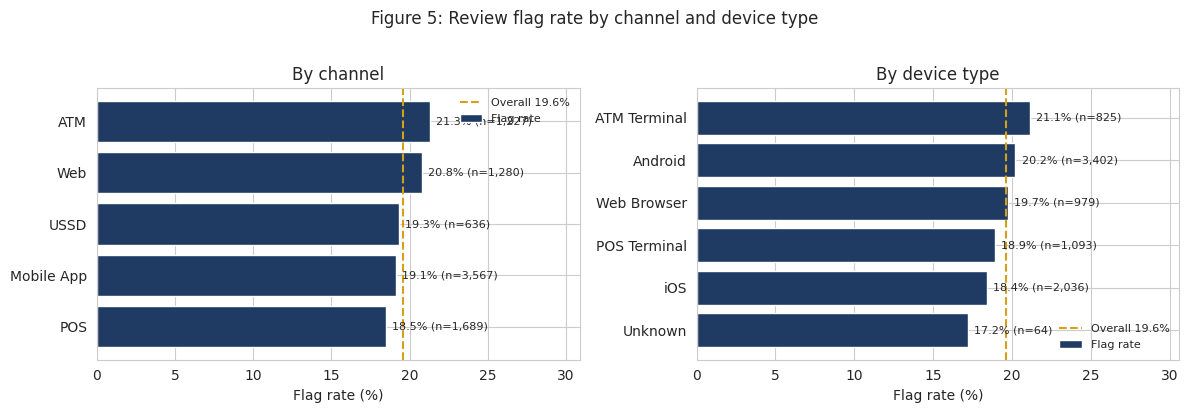

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, column, title in zip(axes, ["Channel", "Device_Type"], ["By channel", "By device type"]):
    plot_flag_rate(ax, train_f, column, title)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Figure 5: Review flag rate by channel and device type", y=1.02)
save_figure(fig, "fig05_channel_device")
plt.show()

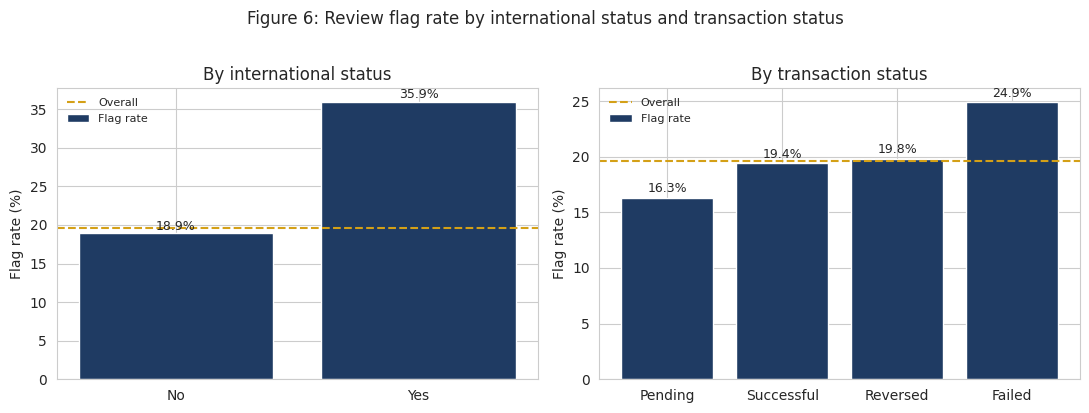

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
overall = train_f["target"].mean() * 100
for ax, column, title in zip(axes, ["International_Transaction", "Transaction_Status"],
                             ["By international status", "By transaction status"]):
    rates = flag_rate_by(train_f, column)
    bars = ax.bar(rates.index.astype(str), rates["flag_rate_pct"], color=NAVY, label="Flag rate")
    for bar, value in zip(bars, rates["flag_rate_pct"]):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.5, f"{value:.1f}%",
                ha="center", fontsize=9)
    ax.axhline(overall, color=GOLD, linestyle="--", linewidth=1.5, label="Overall")
    ax.set(title=title, ylabel="Flag rate (%)")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Figure 6: Review flag rate by international status and transaction status", y=1.02)
save_figure(fig, "fig06_international_status")
plt.show()

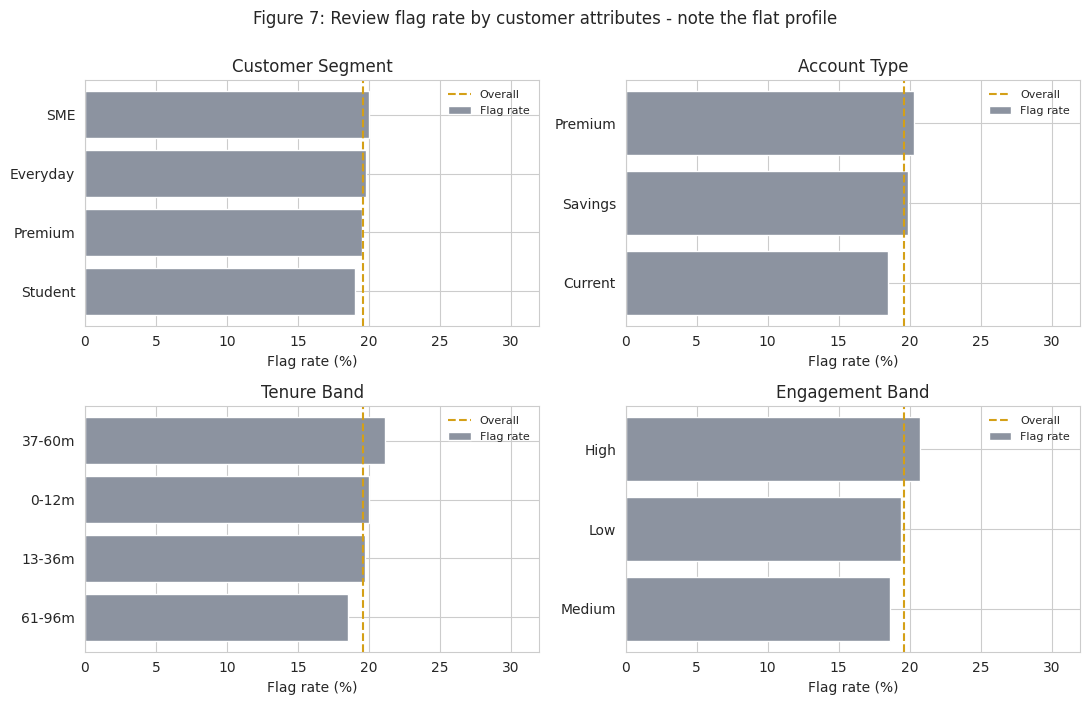

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, column in zip(axes.ravel(),
                      ["Customer_Segment", "Account_Type", "Tenure_Band", "Engagement_Band"]):
    rates = flag_rate_by(train_f, column)
    ax.barh(rates.index.astype(str), rates["flag_rate_pct"], color=GREY, label="Flag rate")
    ax.axvline(train_f["target"].mean() * 100, color=GOLD, linestyle="--",
               linewidth=1.5, label="Overall")
    ax.set(title=column.replace("_", " "), xlabel="Flag rate (%)", xlim=(0, 32))
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Figure 7: Review flag rate by customer attributes - note the flat profile", y=1.0)
save_figure(fig, "fig07_customer_attributes")
plt.show()

**This is the key EDA finding.** Every customer-level attribute sits within about two percentage
points of the overall 19.6% rate, while transaction-level attributes range from 12.7% to 35.9%. The
synthetic label appears to be generated from transaction attributes. Week 1 predicted this and
predicted the performance ceiling that follows from it.

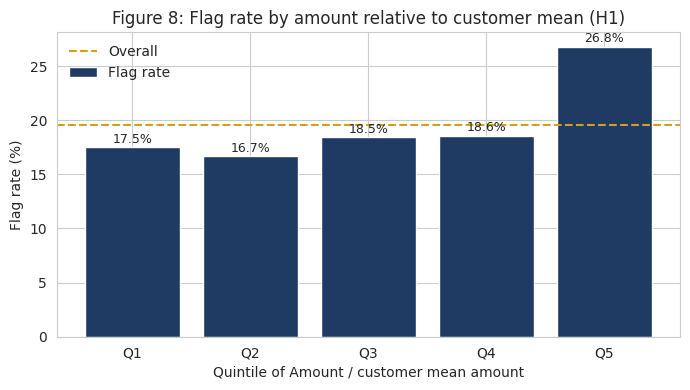

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
train_f["Ratio_Quintile"] = pd.qcut(train_f["Amount_vs_Cust_Mean"], 5,
                                    labels=["Q1", "Q2", "Q3", "Q4", "Q5"]).astype(str)
rates = train_f.groupby("Ratio_Quintile")["target"].mean() * 100
bars = ax.bar(rates.index, rates.values, color=NAVY, label="Flag rate")
for bar, value in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.4, f"{value:.1f}%", ha="center", fontsize=9)
ax.axhline(train_f["target"].mean() * 100, color=GOLD, linestyle="--", linewidth=1.5, label="Overall")
ax.set(title="Figure 8: Flag rate by amount relative to customer mean (H1)",
       xlabel="Quintile of Amount / customer mean amount", ylabel="Flag rate (%)")
ax.legend(frameon=False)
save_figure(fig, "fig08_amount_vs_customer_mean")
plt.show()

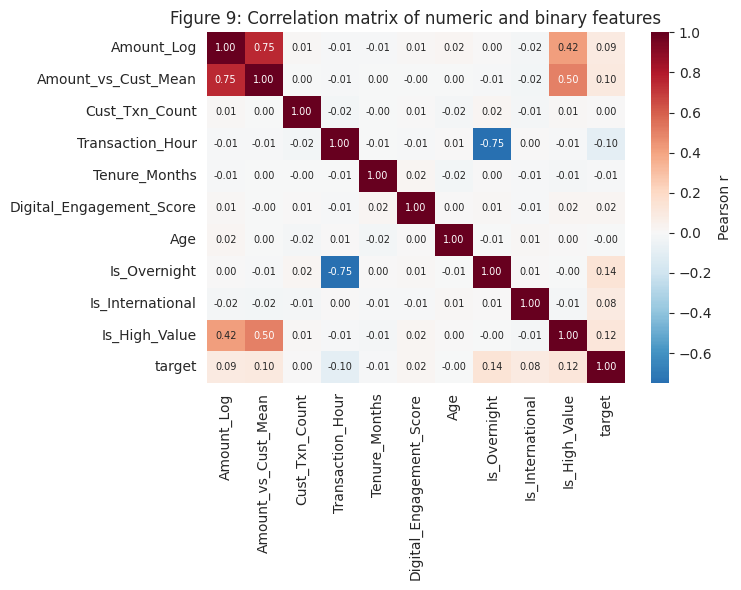

In [28]:
fig, ax = plt.subplots(figsize=(7.5, 6))
numeric_cols = ["Amount_Log", "Amount_vs_Cust_Mean", "Cust_Txn_Count", "Transaction_Hour",
                "Tenure_Months", "Digital_Engagement_Score", "Age", "Is_Overnight",
                "Is_International", "Is_High_Value", "target"]
sns.heatmap(train_f[numeric_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, annot_kws={"size": 7}, cbar_kws={"label": "Pearson r"})
ax.set_title("Figure 9: Correlation matrix of numeric and binary features")
save_figure(fig, "fig09_correlation_matrix")
plt.show()

### B9. Hypothesis testing — H1 to H5 from Week 1

Tested at α = 0.05 with Cramér's V reported alongside each p-value. With 8,399 training records,
statistical significance is easy to obtain; **effect size is what determines whether a variable is
worth modelling**.

In [29]:
def cramers_v(table: pd.DataFrame) -> float:
    """Compute Cramer's V effect size for a contingency table.

    Args:
        table: Contingency table of counts.

    Returns:
        Cramer's V, between 0 (no association) and 1 (perfect association).
    """
    chi2 = stats.chi2_contingency(table)[0]
    n = table.values.sum()
    return float(np.sqrt(chi2 / (n * (min(table.shape) - 1))))


def chi_square_test(data: pd.DataFrame, column: str, label: str) -> dict:
    """Run a chi-square test of independence between a column and the target.

    Args:
        data: Dataset to test.
        column: Categorical column.
        label: Human-readable hypothesis label for printing.

    Returns:
        Dict of chi-square statistic, p-value and Cramer's V.
    """
    table = pd.crosstab(data[column], data["target"])
    chi2, p_value, dof, _ = stats.chi2_contingency(table)
    v = cramers_v(table)
    verdict = "SUPPORTED" if p_value < 0.05 else "NOT SUPPORTED"
    print(f"\n{label}")
    print(f"  chi2 = {chi2:.2f}  dof = {dof}  p = {p_value:.2e}  Cramers V = {v:.3f}  -> {verdict}")
    print("  flag rate (%):", (data.groupby(column)["target"].mean() * 100).round(1).to_dict())
    return {"chi2": chi2, "p": p_value, "v": v}


def two_proportion_z_test(data: pd.DataFrame, mask: pd.Series, label: str) -> dict:
    """Compare the flag rate inside a group against the rest of the data.

    Args:
        data: Dataset to test.
        mask: Boolean mask selecting the group of interest.
        label: Human-readable hypothesis label for printing.

    Returns:
        Dict of z statistic, p-value and the two group rates.
    """
    inside, outside = data.loc[mask, "target"], data.loc[~mask, "target"]
    n1, n2 = len(inside), len(outside)
    p1, p2 = inside.mean(), outside.mean()
    pooled = (inside.sum() + outside.sum()) / (n1 + n2)
    z = (p1 - p2) / np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    verdict = "SUPPORTED" if p_value < 0.05 else "NOT SUPPORTED"
    print(f"\n{label}")
    print(f"  group {p1 * 100:.1f}% (n={n1:,}) vs rest {p2 * 100:.1f}% (n={n2:,})")
    print(f"  z = {z:.2f}  p = {p_value:.2e}  difference = {(p1 - p2) * 100:+.1f}pp  -> {verdict}")
    return {"z": z, "p": p_value, "rate_in": p1, "rate_out": p2}


h1 = chi_square_test(train_f, "Ratio_Quintile", "H1: amount relative to the customer's own mean")
h2 = chi_square_test(train_f, "Tenure_Band", "H2: account tenure band")
h3 = chi_square_test(train_f, "Channel", "H3: transaction channel")
h4a = two_proportion_z_test(train_f, train_f["Is_International"] == 1, "H4a: international transactions")
h4b = chi_square_test(train_f, "Amount_Band", "H4b: transaction amount band")
h5 = two_proportion_z_test(train_f, train_f["Is_Overnight"] == 1, "H5: overnight window 00:00-05:59")


H1: amount relative to the customer's own mean
  chi2 = 71.43  dof = 4  p = 1.13e-14  Cramers V = 0.092  -> SUPPORTED
  flag rate (%): {'Q1': 17.5, 'Q2': 16.7, 'Q3': 18.5, 'Q4': 18.6, 'Q5': 26.8}

H2: account tenure band
  chi2 = 5.77  dof = 3  p = 1.23e-01  Cramers V = 0.026  -> NOT SUPPORTED
  flag rate (%): {'0-12m': 20.0, '13-36m': 19.7, '37-60m': 21.1, '61-96m': 18.5}

H3: transaction channel
  chi2 = 5.02  dof = 4  p = 2.85e-01  Cramers V = 0.024  -> NOT SUPPORTED
  flag rate (%): {'ATM': 21.3, 'Mobile App': 19.1, 'POS': 18.5, 'USSD': 19.3, 'Web': 20.8}

H4a: international transactions
  group 35.9% (n=340) vs rest 18.9% (n=8,059)
  z = 7.72  p = 1.13e-14  difference = +17.0pp  -> SUPPORTED

H4b: transaction amount band
  chi2 = 74.04  dof = 4  p = 3.19e-15  Cramers V = 0.094  -> SUPPORTED
  flag rate (%): {'Q1': 17.2, 'Q2': 17.7, 'Q3': 17.3, 'Q4': 18.8, 'Q5': 27.0}

H5: overnight window 00:00-05:59
  group 28.9% (n=2,131) vs rest 16.4% (n=6,268)
  z = 12.47  p = 0.00e+00  diffe

**Results: 3 of 5 hypotheses supported.**

| ID | Hypothesis | Verdict | Effect |
|---|---|---|---|
| H1 | Amount vs customer's own mean | Supported | Cramér's V = 0.092 — small; top quintile 26.8% vs ~17% |
| H2 | Shorter tenure → higher flag rate | **Not supported** | p = 0.12, V = 0.026 — no gradient |
| H3 | Digital channels → higher flag rate | **Not supported** | p = 0.29, V = 0.024 — spread is 18.5%–21.3% |
| H4 | International and high-value | Supported | International +17.0pp; top amount quintile 27.0% |
| H5 | Overnight 00:00–05:59 | Supported | +12.4pp, z = 12.47 |

H2 and H3 were **predicted to fail in Week 1** on the basis of descriptive profiling, and they did.
Reporting them is more honest than quietly dropping them, and it justifies not spending Week 3
capacity on tenure- or channel-derived features.

Note on H1: the effect is likely **confounded with raw amount**, since a transaction in the top
quintile of a customer's own distribution is usually also large in absolute terms. Disentangling the
two is Week 3 work.

---
# Part D — Baseline Model Development

In [30]:
NUMERIC_FEATURES = ["Amount_Log", "Amount_vs_Cust_Mean", "Cust_Txn_Count", "Transaction_Hour",
                    "Tenure_Months", "Digital_Engagement_Score", "Age"]
BINARY_FEATURES = ["Is_Overnight", "Is_Weekend", "Is_High_Value", "Is_International"]
CATEGORICAL_FEATURES = ["Transaction_Type", "Channel", "Device_Type", "Location", "Amount_Band",
                        "Transaction_DayOfWeek", "Customer_Segment", "Account_Type",
                        "Account_Status", "Monthly_Income_Band", "Preferred_Channel",
                        "Tenure_Band", "Engagement_Band"]


def build_pipeline(model, categorical_features: list[str]) -> Pipeline:
    """Build a preprocessing and model pipeline.

    Scaling and one-hot encoding are fitted inside the pipeline, so when the
    pipeline is used with cross-validation they are refitted on each training
    fold and never see the held-out fold.

    Args:
        model: An unfitted scikit-learn classifier.
        categorical_features: Categorical column names to one-hot encode.

    Returns:
        A Pipeline of preprocessing followed by the model.
    """
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
    ], remainder="passthrough")
    return Pipeline([("prep", preprocessor), ("model", model)])


def feature_columns(categorical_features: list[str]) -> list[str]:
    """Return the ordered list of model input columns."""
    return NUMERIC_FEATURES + BINARY_FEATURES + categorical_features


X_train, y_train = train_f[feature_columns(CATEGORICAL_FEATURES)], train_f["target"]
X_val, y_val = val_f[feature_columns(CATEGORICAL_FEATURES)], val_f["target"]

print(f"Model input: {X_train.shape[1]} raw columns -> expanded by one-hot encoding")
print(f"Training rows: {len(X_train):,} | Validation rows: {len(X_val):,}")

Model input: 24 raw columns -> expanded by one-hot encoding
Training rows: 8,399 | Validation rows: 1,801


In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

candidates = {
    "Logistic Regression (baseline)": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, class_weight="balanced", random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1),
}

results = {}
for name, model in candidates.items():
    pipeline = build_pipeline(model, CATEGORICAL_FEATURES)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_val)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    results[name] = {
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std(),
        "val_auc": roc_auc_score(y_val, probabilities),
        "val_pr_auc": average_precision_score(y_val, probabilities),
        "val_accuracy": accuracy_score(y_val, predictions),
        "val_precision": precision_score(y_val, predictions, zero_division=0),
        "val_recall": recall_score(y_val, predictions),
        "val_f1": f1_score(y_val, predictions),
        "pipeline": pipeline,
        "probabilities": probabilities,
    }

comparison = pd.DataFrame({k: {kk: vv for kk, vv in v.items()
                               if kk not in ("pipeline", "probabilities")}
                           for k, v in results.items()}).T
comparison.round(4)

,cv_auc_mean,cv_auc_std,val_auc,val_pr_auc,val_accuracy,val_precision,val_recall,val_f1
Logistic Regression (baseline),0.6650,0.0174,0.6742,0.3131,0.6130,0.2897,0.6714,0.4048
Decision Tree,0.6522,0.0228,0.6253,0.2954,0.5997,0.2756,0.6402,0.3853
Random Forest,0.6695,0.0158,0.6768,0.3498,0.7879,0.4293,0.2493,0.3154


---
# Part E — Model Evaluation

### E1. Why these metrics

| Metric | Why it is used here |
|---|---|
| **ROC-AUC** | Threshold-independent. The operating point will move as review capacity changes, so a metric that does not depend on one threshold is the right primary measure. |
| **PR-AUC** | With a 19.6% positive class, PR-AUC is more informative than ROC-AUC about minority-class performance. |
| **Recall** | A missed review is the costlier error in a triage setting. This is the binding operational constraint. |
| **Precision** | Determines how much analyst time is spent on transactions that did not need review. |
| **F1** | Single balanced summary for comparing models at a fixed threshold. |
| **Confusion matrix** | Converts rates into actual case counts, which is what a reviewer experiences. |
| **Accuracy** | Reported but **not used for selection** — predicting "No" for everything scores 80.4%. |

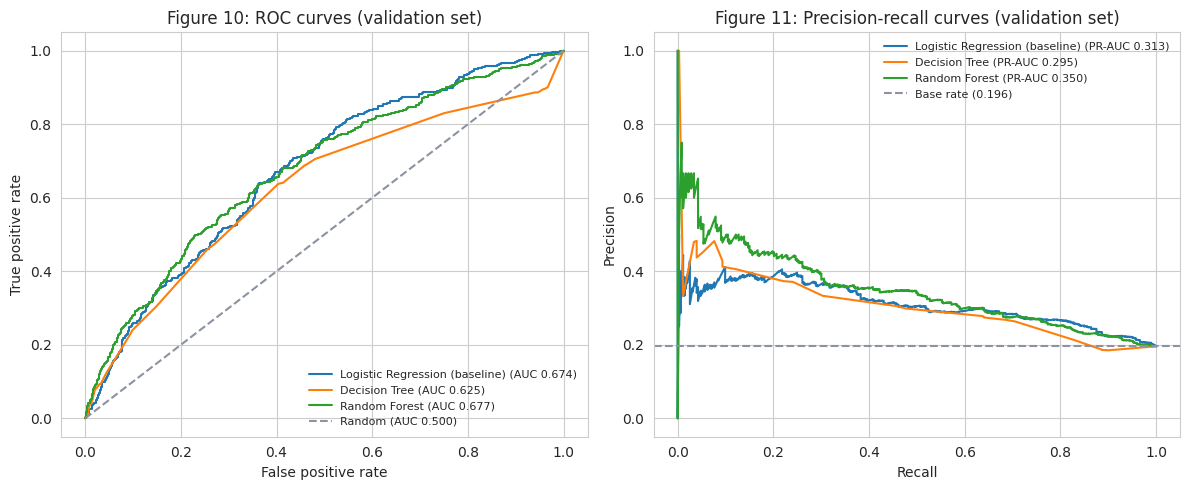

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_val, result["probabilities"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC {result['val_auc']:.3f})")
    precision_curve, recall_curve, _ = precision_recall_curve(y_val, result["probabilities"])
    axes[1].plot(recall_curve, precision_curve,
                 label=f"{name} (PR-AUC {result['val_pr_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], "--", color=GREY, label="Random (AUC 0.500)")
axes[0].set(title="Figure 10: ROC curves (validation set)",
            xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")

axes[1].axhline(y_val.mean(), linestyle="--", color=GREY, label=f"Base rate ({y_val.mean():.3f})")
axes[1].set(title="Figure 11: Precision-recall curves (validation set)",
            xlabel="Recall", ylabel="Precision")
axes[1].legend(frameon=False, fontsize=8)
save_figure(fig, "fig10_roc_and_pr_curves")
plt.show()

### E2. Threshold selection — meeting the recall ≥ 0.70 constraint

In [33]:
baseline = results["Logistic Regression (baseline)"]
val_probabilities = baseline["probabilities"]

precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, val_probabilities)
eligible = np.where(recall_curve[:-1] >= 0.70)[0]
chosen_threshold = thresholds[eligible[-1]]
tuned_predictions = (val_probabilities >= chosen_threshold).astype(int)

print(f"Chosen threshold: {chosen_threshold:.4f}\n")
for label, preds in [("Default 0.50", (val_probabilities >= 0.5).astype(int)),
                     (f"Tuned {chosen_threshold:.3f}", tuned_predictions)]:
    print(f"{label:16s} recall {recall_score(y_val, preds):.3f} | "
          f"precision {precision_score(y_val, preds):.3f} | "
          f"F1 {f1_score(y_val, preds):.3f} | accuracy {accuracy_score(y_val, preds):.3f}")

# Operational value: how much better than random allocation of review effort?
order = np.argsort(-val_probabilities)
top_decile = order[:int(len(val_probabilities) * 0.1)]
lift = y_val.values[top_decile].mean() / y_val.mean()
print(f"\nTop-decile lift: {y_val.values[top_decile].mean() * 100:.1f}% flagged "
      f"vs {y_val.mean() * 100:.1f}% base = {lift:.2f}x better than random")

Chosen threshold: 0.4875

Default 0.50     recall 0.671 | precision 0.290 | F1 0.405 | accuracy 0.613
Tuned 0.488      recall 0.703 | precision 0.283 | F1 0.404 | accuracy 0.594

Top-decile lift: 38.3% flagged vs 19.6% base = 1.96x better than random


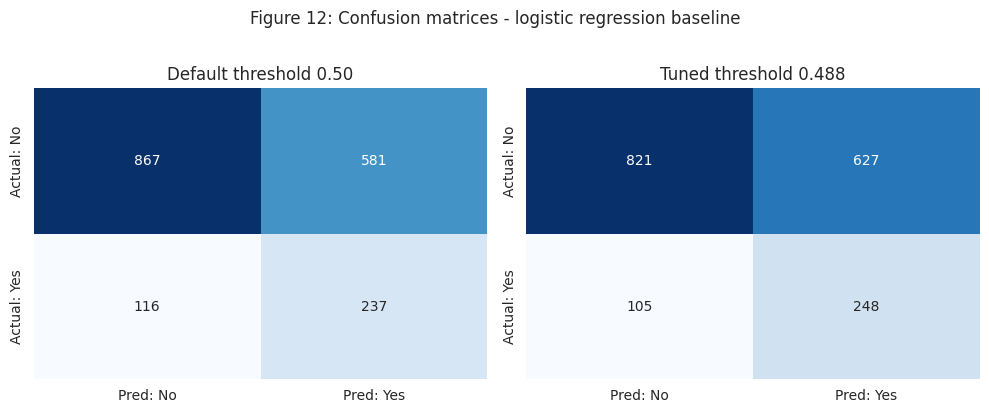

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
matrices = [("Default threshold 0.50", confusion_matrix(y_val, (val_probabilities >= 0.5).astype(int))),
            (f"Tuned threshold {chosen_threshold:.3f}", confusion_matrix(y_val, tuned_predictions))]
for ax, (title, matrix) in zip(axes, matrices):
    sns.heatmap(matrix, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred: No", "Pred: Yes"], yticklabels=["Actual: No", "Actual: Yes"])
    ax.set_title(title)
fig.suptitle("Figure 12: Confusion matrices - logistic regression baseline", y=1.02)
save_figure(fig, "fig12_confusion_matrices")
plt.show()

### E3. Leakage test — does `Transaction_Status` inflate performance?

In [35]:
CATEGORICAL_WITH_STATUS = CATEGORICAL_FEATURES + ["Transaction_Status"]

leakage_pipeline = build_pipeline(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    CATEGORICAL_WITH_STATUS)
leakage_cv = cross_val_score(leakage_pipeline, train_f[feature_columns(CATEGORICAL_WITH_STATUS)],
                             y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
leakage_pipeline.fit(train_f[feature_columns(CATEGORICAL_WITH_STATUS)], y_train)
leakage_auc = roc_auc_score(y_val, leakage_pipeline.predict_proba(
    val_f[feature_columns(CATEGORICAL_WITH_STATUS)])[:, 1])

print(f"WITHOUT Transaction_Status:  CV {baseline['cv_auc_mean']:.4f}  Val {baseline['val_auc']:.4f}")
print(f"WITH    Transaction_Status:  CV {leakage_cv.mean():.4f}  Val {leakage_auc:.4f}")
print(f"Difference:                  CV {leakage_cv.mean() - baseline['cv_auc_mean']:+.4f}  "
      f"Val {leakage_auc - baseline['val_auc']:+.4f}")

WITHOUT Transaction_Status:  CV 0.6650  Val 0.6742
WITH    Transaction_Status:  CV 0.6685  Val 0.6812
Difference:                  CV +0.0035  Val +0.0070


**Decision.** Including `Transaction_Status` adds only about +0.007 ROC-AUC. Because the gain is
negligible and the field carries a genuine leakage risk — status may be set *after* a review
decision — it is **excluded from the baseline**. A field that might leak and barely helps is not
worth the methodological exposure.

### E4. Grouped-split sensitivity — are the rows really independent?

In [36]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_SEED)
group_train_idx, group_val_idx = next(
    splitter.split(train_val, train_val["target"], groups=train_val["Customer_ID"]))

group_train = engineer_features(train_val.iloc[group_train_idx])
group_val = engineer_features(train_val.iloc[group_val_idx])

group_pipeline = build_pipeline(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    CATEGORICAL_FEATURES)
group_pipeline.fit(group_train[feature_columns(CATEGORICAL_FEATURES)], group_train["target"])
group_auc = roc_auc_score(group_val["target"],
                          group_pipeline.predict_proba(
                              group_val[feature_columns(CATEGORICAL_FEATURES)])[:, 1])

print(f"Random split  ROC-AUC: {baseline['val_auc']:.4f}")
print(f"Grouped split ROC-AUC: {group_auc:.4f}   difference {group_auc - baseline['val_auc']:+.4f}")

Random split  ROC-AUC: 0.6742
Grouped split ROC-AUC: 0.6759   difference +0.0017


The two are effectively identical, which **resolves risk R4 from the Week 1 register**. Because
customer attributes carry almost no signal, sharing customers between train and validation gives the
model nothing to memorise. The non-independence concern was real in principle but is immaterial here.

---
# Part F — Model Interpretation

In [37]:
pipeline = baseline["pipeline"]
feature_names = pipeline.named_steps["prep"].get_feature_names_out()
coefficients = pipeline.named_steps["model"].coef_[0]

coef_table = (pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
              .assign(magnitude=lambda t: t["coefficient"].abs())
              .sort_values("magnitude", ascending=False))
print("Top 15 logistic regression coefficients (log-odds):")
print(coef_table.head(15).to_string(index=False))

Top 15 logistic regression coefficients (log-odds):
                              feature  coefficient  magnitude
          remainder__Is_International     0.951189   0.951189
              remainder__Is_Overnight     0.847976   0.847976
                  cat__Amount_Band_Q5    -0.705231   0.705231
             remainder__Is_High_Value     0.612013   0.612013
       cat__Transaction_Type_Transfer     0.596131   0.596131
                  cat__Amount_Band_Q4    -0.592678   0.592678
cat__Transaction_Type_Cash Withdrawal     0.578882   0.578882
             cat__Device_Type_Unknown    -0.474845   0.474845
                  cat__Amount_Band_Q3    -0.452733   0.452733
   cat__Transaction_Type_Bill Payment    -0.329009   0.329009
  cat__Transaction_Type_Card Purchase    -0.301380   0.301380
        cat__Transaction_Type_Deposit    -0.286212   0.286212
                      num__Amount_Log     0.283578   0.283578
                  cat__Amount_Band_Q2    -0.247133   0.247133
       cat__Accoun

Permutation importance (drop in validation ROC-AUC when the column is shuffled):
            feature  importance      std
   Transaction_Type    0.071153 0.008604
       Is_Overnight    0.048556 0.007675
        Amount_Band    0.019604 0.003409
         Amount_Log    0.017739 0.005021
   Is_International    0.007989 0.003316
      Is_High_Value    0.005805 0.001398
       Account_Type    0.003764 0.002028
    Engagement_Band    0.003501 0.002267
Amount_vs_Cust_Mean    0.003342 0.007059
        Tenure_Band    0.003056 0.001160
            Channel    0.002307 0.001419
           Location    0.001426 0.002007


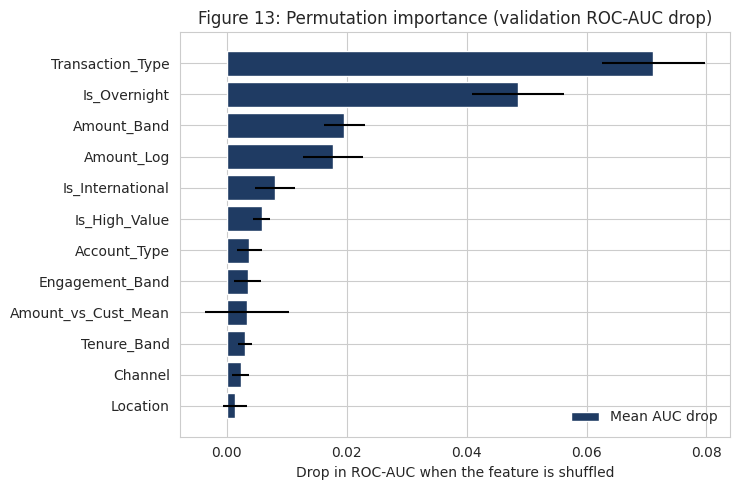

In [38]:
perm = permutation_importance(pipeline, X_val, y_val, n_repeats=10,
                              random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=-1)
importance = (pd.DataFrame({"feature": X_val.columns,
                            "importance": perm.importances_mean,
                            "std": perm.importances_std})
              .sort_values("importance", ascending=False))
print("Permutation importance (drop in validation ROC-AUC when the column is shuffled):")
print(importance.head(12).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 5))
top = importance.head(12).iloc[::-1]
ax.barh(top["feature"], top["importance"], xerr=top["std"], color=NAVY, label="Mean AUC drop")
ax.set(title="Figure 13: Permutation importance (validation ROC-AUC drop)",
       xlabel="Drop in ROC-AUC when the feature is shuffled")
ax.legend(frameon=False)
save_figure(fig, "fig13_permutation_importance")
plt.show()

**Why permutation importance is trusted over the coefficients here.** The coefficient table shows
`Amount_Band_Q5` with a *negative* sign while `Amount_Log` is positive — which would read as "larger
amounts lower the risk". That is a multicollinearity artefact: `Amount_Log`, `Amount_Band` and
`Is_High_Value` all encode the same underlying quantity, so the model splits the effect across them
arbitrarily. Permutation importance measures each column's actual contribution to predictive
performance and is not distorted in this way. **Week 3 action:** drop the redundant amount encodings
and keep one.

### F2. Error analysis — where does the model succeed and fail?

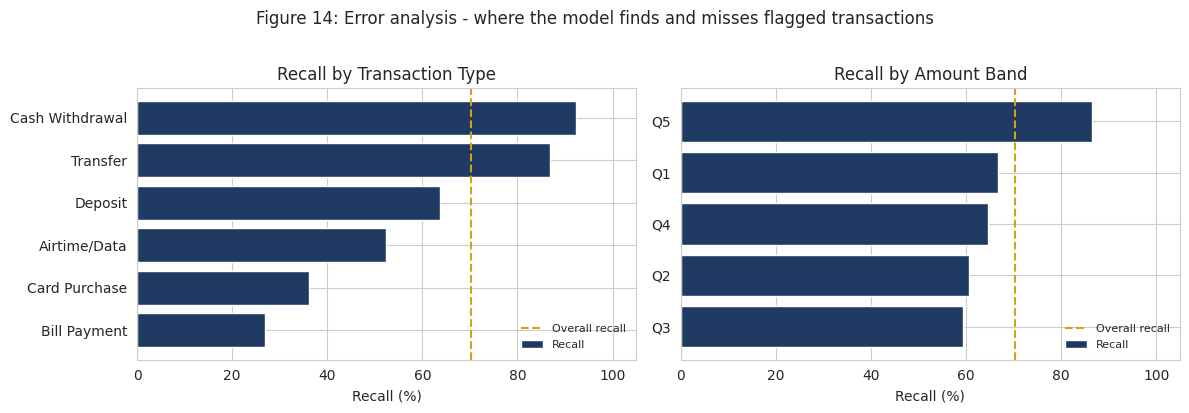


Recall by Transaction_Type:
                      n  actual_rate_pct  recall_pct
Transaction_Type                                    
Airtime/Data      166.0             12.7        52.4
Bill Payment      209.0             12.4        26.9
Card Purchase     470.0             13.0        36.1
Cash Withdrawal   193.0             26.9        92.3
Deposit           202.0             16.3        63.6
Transfer          561.0             28.5        86.9

Recall by Is_Overnight:
                   n  actual_rate_pct  recall_pct
Is_Overnight                                     
0             1361.0             16.6        59.3
1              440.0             28.9        89.8

Recall by Is_International:
                       n  actual_rate_pct  recall_pct
Is_International                                     
0                 1736.0             19.1        68.7
1                   65.0             32.3        95.2


In [39]:
val_errors = val_f.copy()
val_errors["prediction"] = tuned_predictions
val_errors["probability"] = val_probabilities

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
overall_recall = recall_score(y_val, tuned_predictions) * 100
for ax, column in zip(axes, ["Transaction_Type", "Amount_Band"]):
    segment_recall = (val_errors.groupby(column)
                      .apply(lambda g: recall_score(g["target"], g["prediction"],
                                                    zero_division=0) * 100)
                      .sort_values())
    ax.barh(segment_recall.index.astype(str), segment_recall.values, color=NAVY, label="Recall")
    ax.axvline(overall_recall, color=GOLD, linestyle="--", linewidth=1.5, label="Overall recall")
    ax.set(title=f"Recall by {column.replace('_', ' ')}", xlabel="Recall (%)", xlim=(0, 105))
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Figure 14: Error analysis - where the model finds and misses flagged transactions", y=1.02)
save_figure(fig, "fig14_error_analysis")
plt.show()

for column in ["Transaction_Type", "Is_Overnight", "Is_International"]:
    summary = val_errors.groupby(column).apply(lambda g: pd.Series({
        "n": len(g),
        "actual_rate_pct": g["target"].mean() * 100,
        "recall_pct": recall_score(g["target"], g["prediction"], zero_division=0) * 100,
    }))
    print(f"\nRecall by {column}:\n{summary.round(1).to_string()}")

### F3. Interpretation summary

| Feature | Evidence | Interpretation |
|---|---|---|
| `Transaction_Type` | Largest permutation importance (0.071 AUC drop) | Transfers (28.5%) and cash withdrawals (26.9%) drive most of the signal; bill payments and card purchases sit near 12–13% |
| `Is_Overnight` | Second largest (0.049); +12.4pp flag rate; coefficient +0.85 | The 00:00–05:59 window is the strongest single binary indicator |
| `Amount_Band` / `Amount_Log` | 0.020 and 0.018 | Amount matters mainly in the top quintile, not linearly |
| `Is_International` | 0.008; +17.0pp flag rate; largest coefficient (+0.95) | Large effect per transaction, but only 4% of transactions, so limited aggregate importance |
| Customer features | All below 0.004 | Segment, tenure, income and engagement contribute almost nothing — consistent with the EDA and with H2's rejection |

### F4. Limitations

**Model limitations**
- ROC-AUC of 0.665 (CV) is **below the 0.75 target set in Week 1**. This is reported as the result, not tuned away.
- At the tuned threshold, precision is 0.283 — roughly 2.5 unnecessary reviews for every genuine one.
- No hyperparameter tuning has been performed yet; that is Week 3 work.

**Data limitations**
- The label is synthetic and its generating rule is undocumented.
- Temporal structure is uniform by construction, so no seasonality analysis is credible.
- Customer attributes are point-in-time, not as-at-transaction-date.
- `Channel` and `Device_Type` are internally inconsistent, limiting their joint interpretation.

**Possible sources of bias**
- The label records a *review decision*, not a confirmed outcome, so any selection bias in the original process is learned by the model.
- `Gender` is excluded by design; `Age` and `Monthly_Income_Band` are retained as candidates but show negligible importance and are candidates for removal in Week 3 on fairness grounds.
- The 4% international subgroup is small, so its coefficient is estimated from relatively few cases.

**Areas requiring further investigation**
- Disentangle H1 from raw amount — is customer-relative deviation adding anything beyond absolute size?
- Remove the redundant amount encodings and re-estimate coefficients.
- Test interaction terms (international × high value; overnight × transfer).
- Fit gradient boosting in Week 3 to test whether non-linear interactions lift performance above the linear ceiling.

---
## Week 2 summary

| Question | Answer |
|---|---|
| Best cross-validated model | Random forest, ROC-AUC 0.670 (±0.016); logistic regression baseline 0.665 (±0.017) |
| Did we meet the Week 1 target? | **No** — 0.67 against a target of 0.75. Predicted in Week 1 and reported as a finding. |
| Recall at the tuned threshold | 0.703, meeting the ≥ 0.70 constraint, at a precision cost of 0.283 |
| Operational value | Top-decile lift of 1.96× over random allocation of review effort |
| Hypotheses supported | H1, H4, H5 supported; H2 and H3 rejected — both predicted to fail in Week 1 |
| Leakage resolved? | Yes — `Transaction_Status` adds only +0.007 AUC and is excluded |
| Risk R4 resolved? | Yes — grouped split matches random split within 0.002 AUC |

**Week 3 priorities:** hyperparameter tuning, gradient boosting, removal of redundant amount
encodings, interaction terms, and a full threshold and cost analysis.

---

*Synthetic data — educational use only. `Risk_Review_Flag` is not a real fraud determination.*